#***Tech Challenge - Fase 2***

# Identificação do participante
Turma = Data Analytics - BB - 2DTATBB  
Grupo = 42  
Usuário = "RM377824"  
Nome = Diana da Silva Miranda  
E-Mail = dianasmirandam@gmail.com  


#Projeto
**Predição de Risco de Crédito Utilizando Machine Learning**

## Contextualização

Imagine uma instituição financeira recebendo milhares de pedidos de cartão de crédito todos os dias.

Diante desse volume de solicitações, surge um desafio: **como tomar decisões de forma rápida e eficiente, reduzindo o risco de conceder crédito a clientes que podem apresentar dificuldades para honrar seus pagamentos?**

É nesse contexto que os dados podem fazer a diferença.

A partir de informações sobre o perfil dos clientes, como renda, ocupação, estado civil e histórico de trabalho, técnicas de **Machine Learning** podem ser utilizadas para identificar padrões e apoiar a avaliação do risco de crédito, permitindo classificar os clientes entre **bons e maus pagadores**.

Neste projeto, exploraremos esses dados para investigar **como modelos de aprendizado de máquina podem contribuir para uma tomada de decisão mais eficiente e segura na concessão de crédito.**

#Importar bibliotecas

Comandos para importar algumas das bibliotecas necessárias para execução do notebook. Ao longo do desenvolvimento, se necessário, incluirei outras bibliotecas.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import numpy, matplotlib, seaborn, sklearn;
print('numpy:', numpy.__version__); print('matplotlib:', matplotlib.__version__); print('seaborn:', seaborn.__version__); print('scikit-learn:', sklearn.__version__)

numpy: 2.1.3
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1



Bases que serão utilizadas no desenvolvimento do trabalho: **application_record.csv** e **credit_record.csv**

In [6]:
#Realizar a leitura da base de dado application_record.csv
applrecord = pd.read_csv('application_record.csv', sep = ',')

In [7]:
#Analisando os primeiros dados
applrecord.head(3)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0


In [8]:
#Analisando os últimos dados
applrecord.tail(3)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0
438556,6842885,F,N,Y,0,121500.0,Working,Secondary / secondary special,Married,House / apartment,-18858,-1201,1,0,1,0,Sales staff,2.0


In [9]:
#Identificar a quantidade de linhas, quantidade de colunas do dataframe
applrecord.shape

(438557, 18)

In [10]:
#Identificar a quantidade de registros por coluna
applrecord.count()

,0
ID,438557
CODE_GENDER,438557
FLAG_OWN_CAR,438557
FLAG_OWN_REALTY,438557
CNT_CHILDREN,438557
AMT_INCOME_TOTAL,438557
NAME_INCOME_TYPE,438557
NAME_EDUCATION_TYPE,438557
NAME_FAMILY_STATUS,438557
NAME_HOUSING_TYPE,438557


Nota: Podemos observar que Occupation_type tem valores faltantes.

In [11]:
#Identificação de valores duplicados
applrecord.duplicated().sum()

np.int64(0)

Nota: Não há valores duplicados na base 'application_record.csv'

#Leitura da base credit_record.csv

In [12]:
#Realizar a leitura da base de dado credit_record.csv
credrecord = pd.read_csv('credit_record.csv', sep = ',')

In [13]:
#Analisando os primeiros dados
credrecord.head(3)

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0


In [14]:
#Analisando os últimos dados
credrecord.tail(3)

,ID,MONTHS_BALANCE,STATUS
1048572,5150487,-27,C
1048573,5150487,-28,C
1048574,5150487,-29,C


In [15]:
#Identificar a quantidade de linhas, quantidade de colunas do dataframe
credrecord.shape

(1048575, 3)

In [16]:
##Identificar a quantidade de registros por coluna
credrecord.count()

,0
ID,1048575
MONTHS_BALANCE,1048575
STATUS,1048575


Nota: Podemos observar que nessa base não há dados faltantes.

In [17]:
#Identificação de valores duplicados
credrecord.duplicated().sum()

np.int64(0)

Nota: Não há valores duplicados na base 'credit_record.csv'

# Merge das tabelas lidas anteriormente

In [18]:
#Fazer o Merge das duas tabelas para geração da tabela que será utilizada na análise de dados.
tabela_final = pd.merge(applrecord, credrecord, on="ID", how="inner")
tabela_final.head(10)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C
5,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-5,C
6,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-6,C
7,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-7,C
8,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-8,C
9,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-9,C


#Analisando os dados

In [19]:
tabela_final.shape

(777715, 20)

In [20]:
#Listagem das colunas do dataframe gerado.
tabela_final.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE',
       'STATUS'],
      dtype='object')

In [21]:
#Resumo detalhado e técnico do DataFrame
tabela_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  object 
 2   FLAG_OWN_CAR         777715 non-null  object 
 3   FLAG_OWN_REALTY      777715 non-null  object 
 4   CNT_CHILDREN         777715 non-null  int64  
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  object 
 7   NAME_EDUCATION_TYPE  777715 non-null  object 
 8   NAME_FAMILY_STATUS   777715 non-null  object 
 9   NAME_HOUSING_TYPE    777715 non-null  object 
 10  DAYS_BIRTH           777715 non-null  int64  
 11  DAYS_EMPLOYED        777715 non-null  int64  
 12  FLAG_MOBIL           777715 non-null  int64  
 13  FLAG_WORK_PHONE      777715 non-null  int64  
 14  FLAG_PHONE           777715 non-null  int64  
 15  FLAG_EMAIL       

# Qualidade dos dados e identificação de valores nulos¶

In [22]:
#Tabela final
tabela_final_nulos = round(tabela_final.isnull().sum() / len(tabela_final), 2)

In [23]:
# Cria um novo DataFrame com os resultados
tabela_final_percentual_nulos = tabela_final_nulos.reset_index()
tabela_final_percentual_nulos.columns = ['Atributo',	'Percentual_Nulos']
tabela_final_percentual_nulos

,Atributo,Percentual_Nulos
0,ID,0.00
1,CODE_GENDER,0.00
2,FLAG_OWN_CAR,0.00
3,FLAG_OWN_REALTY,0.00
4,CNT_CHILDREN,0.00
5,AMT_INCOME_TOTAL,0.00
6,NAME_INCOME_TYPE,0.00
7,NAME_EDUCATION_TYPE,0.00
8,NAME_FAMILY_STATUS,0.00
9,NAME_HOUSING_TYPE,0.00


<Axes: >

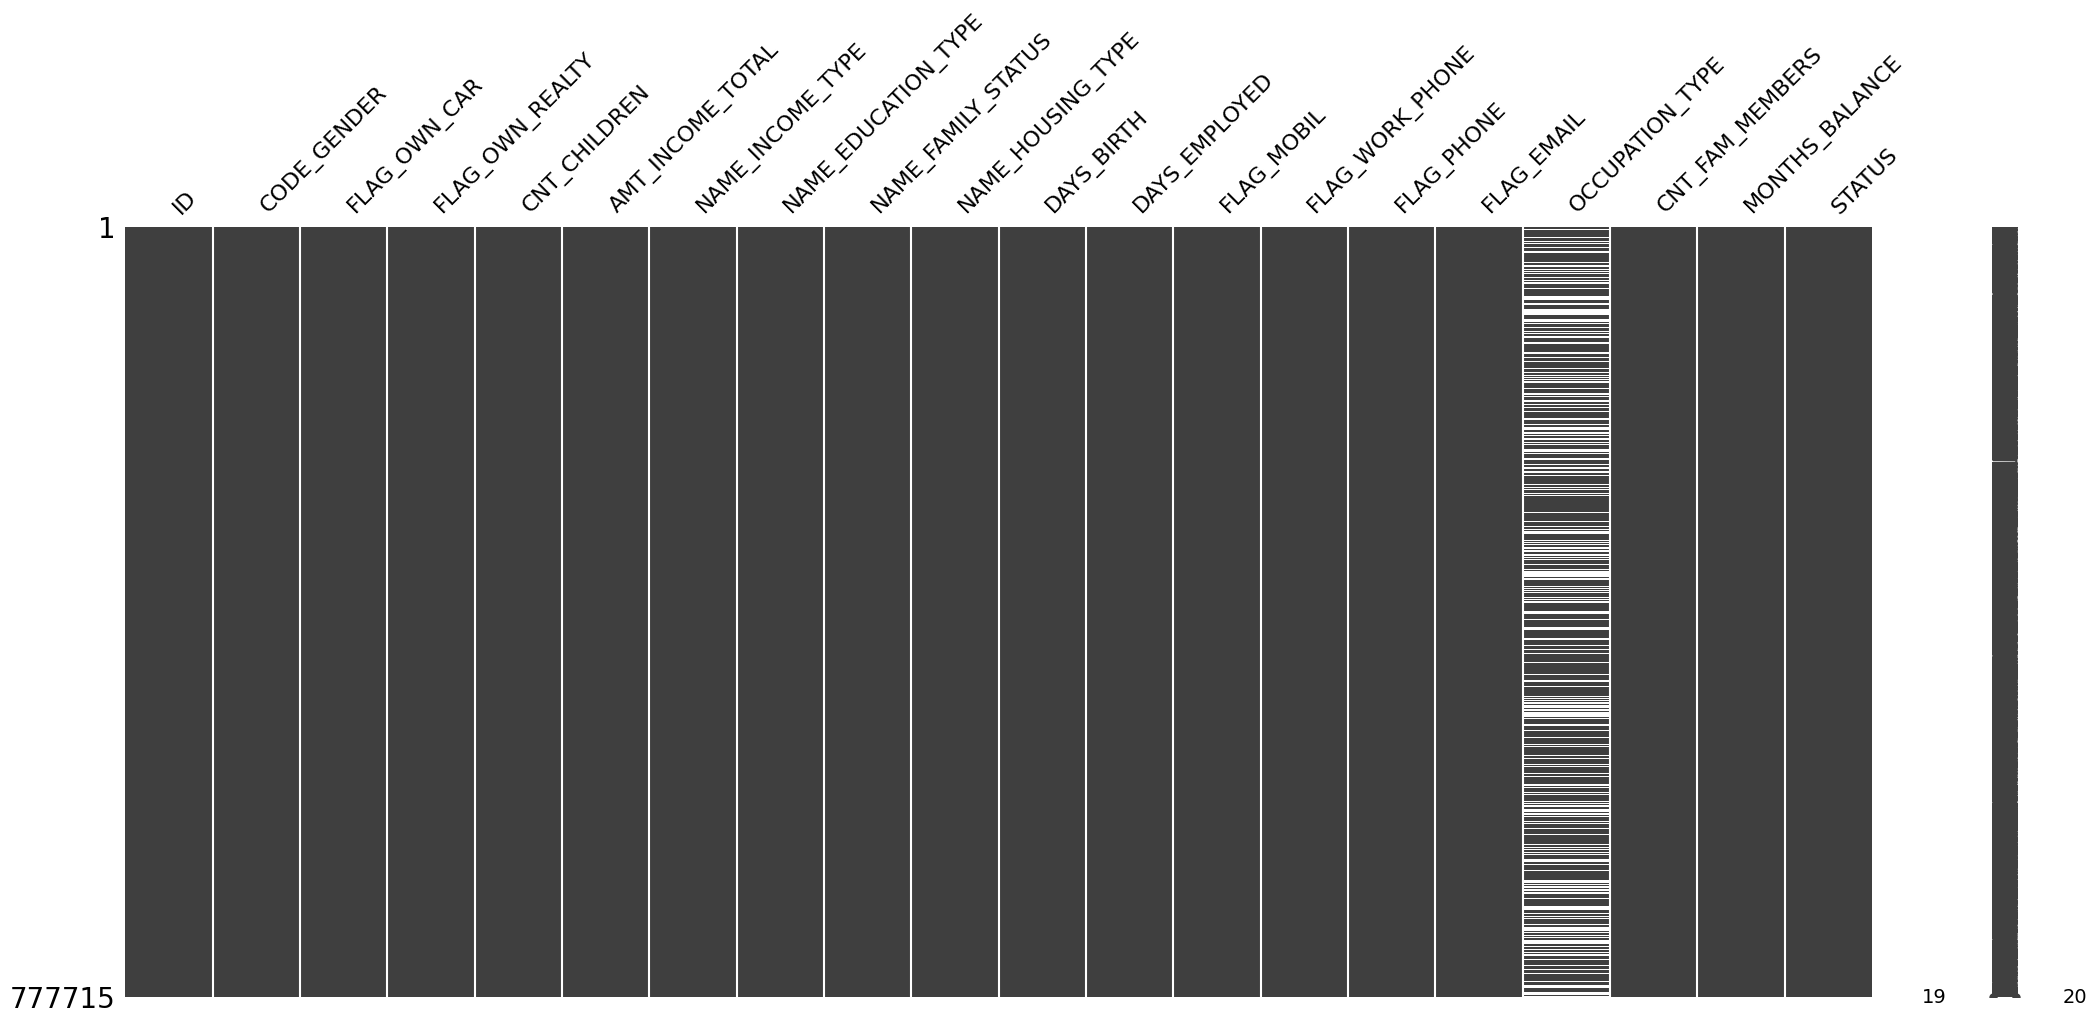

In [24]:
#Uma outra forma de visualizar valores nulos
import missingno as msno
msno.matrix(tabela_final)

# Análise exploratória dos dados

In [25]:
#Gerar um resumo estatístico das colunas numéricas do DataFrame.
tabela_final.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,777715.0,5.078743e+06,41804.424817,5008804.0,5044568.5,5069530.0,5115551.0,5150487.0
CNT_CHILDREN,777715.0,4.280823e-01,0.745755,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,777715.0,1.885348e+05,101622.450076,27000.0,121500.0,162000.0,225000.0,1575000.0
DAYS_BIRTH,777715.0,-1.612494e+04,4104.304018,-25152.0,-19453.0,-15760.0,-12716.0,-7489.0
DAYS_EMPLOYED,777715.0,5.777583e+04,136471.735391,-15713.0,-3292.0,-1682.0,-431.0,365243.0
FLAG_MOBIL,777715.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,777715.0,2.318176e-01,0.421993,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,777715.0,3.009650e-01,0.458678,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,777715.0,9.167497e-02,0.288567,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,777715.0,2.208837e+00,0.907380,1.0,2.0,2.0,3.0,20.0


#Algumas visualizações para entendimento dos dados

In [26]:
#Importe da biblioteca Seaborn
# permite que crie gráficos rapidamente com apenas algumas linhas de código, facilitando a exploração de dados
import seaborn as sb

<Axes: xlabel='AMT_INCOME_TOTAL'>

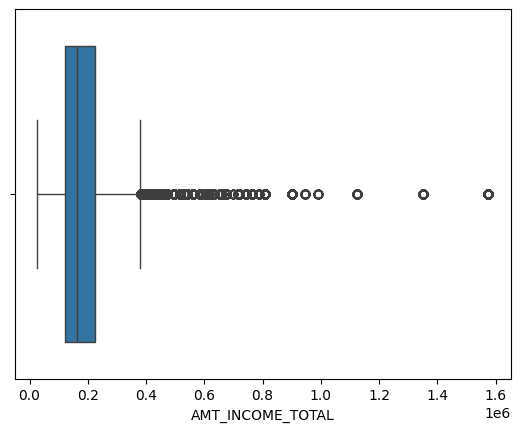

In [27]:
sb.boxplot(x=tabela_final["AMT_INCOME_TOTAL"])

<Axes: xlabel='DAYS_BIRTH'>

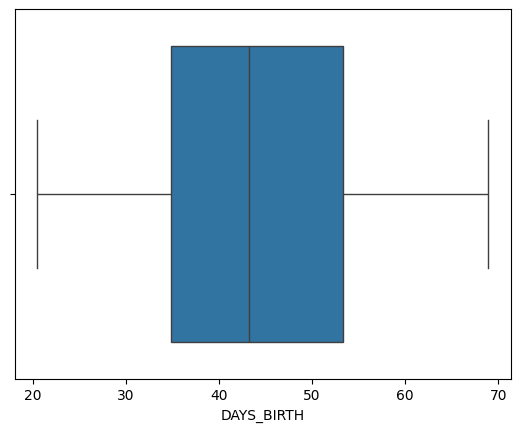

In [28]:
sb.boxplot(x=abs(tabela_final["DAYS_BIRTH"]) / 365)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Working'),
  Text(1, 0, 'Commercial associate'),
  Text(2, 0, 'Pensioner'),
  Text(3, 0, 'State servant'),
  Text(4, 0, 'Student')])

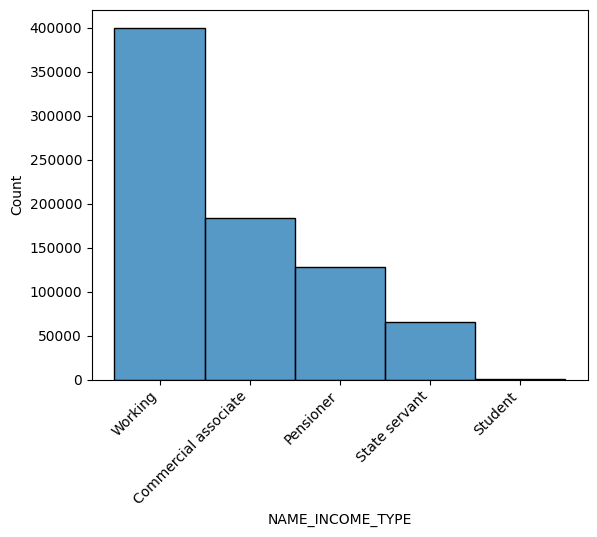

In [29]:
sb.histplot(data=tabela_final, x="NAME_INCOME_TYPE")
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Higher education'),
  Text(1, 0, 'Secondary / secondary special'),
  Text(2, 0, 'Incomplete higher'),
  Text(3, 0, 'Lower secondary'),
  Text(4, 0, 'Academic degree')])

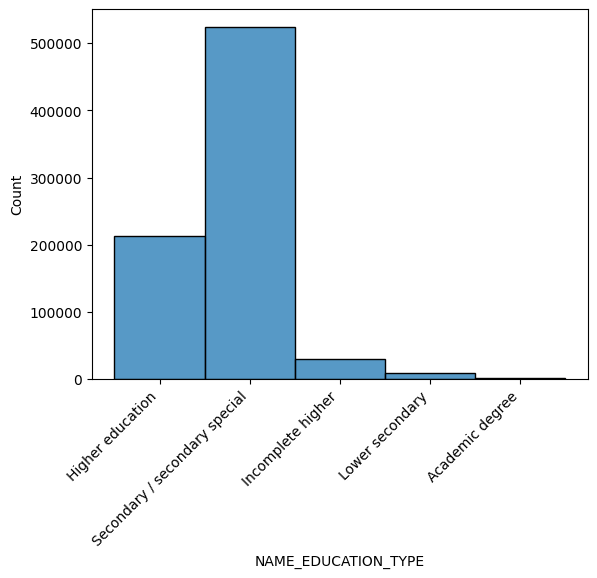

In [30]:
sb.histplot(data=tabela_final, x="NAME_EDUCATION_TYPE")
plt.xticks(rotation=45, ha='right')

<Axes: xlabel='STATUS', ylabel='OCCUPATION_TYPE'>

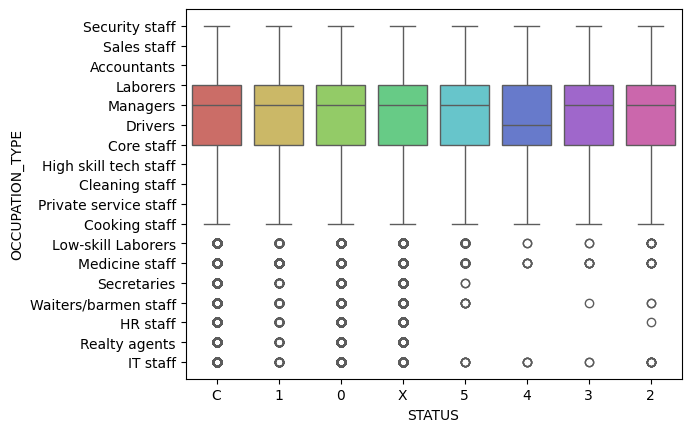

In [31]:
sb.boxplot(x='STATUS', y='OCCUPATION_TYPE', data=tabela_final, palette='hls', legend=False, hue='STATUS')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Working'),
  Text(1, 0, 'Commercial associate'),
  Text(2, 0, 'Pensioner'),
  Text(3, 0, 'State servant'),
  Text(4, 0, 'Student')])

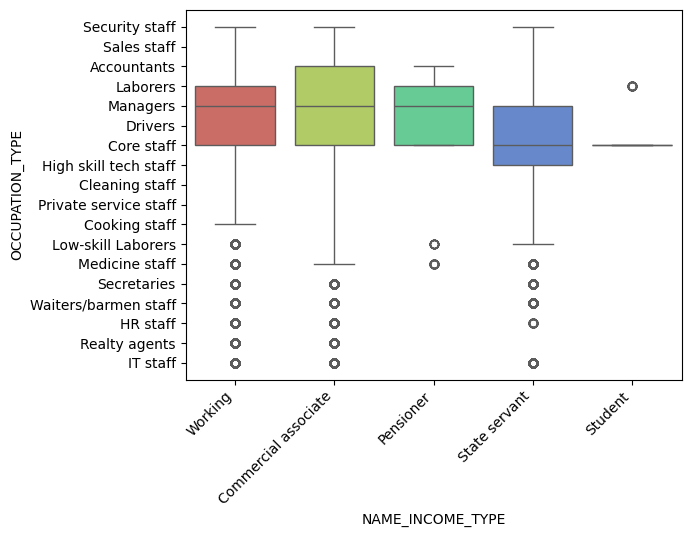

In [32]:
sb.boxplot(x='NAME_INCOME_TYPE', y='OCCUPATION_TYPE', data=tabela_final, palette='hls',legend=False, hue='NAME_INCOME_TYPE')
plt.xticks(rotation=45, ha='right')

<Axes: xlabel='AMT_INCOME_TOTAL', ylabel='NAME_INCOME_TYPE'>

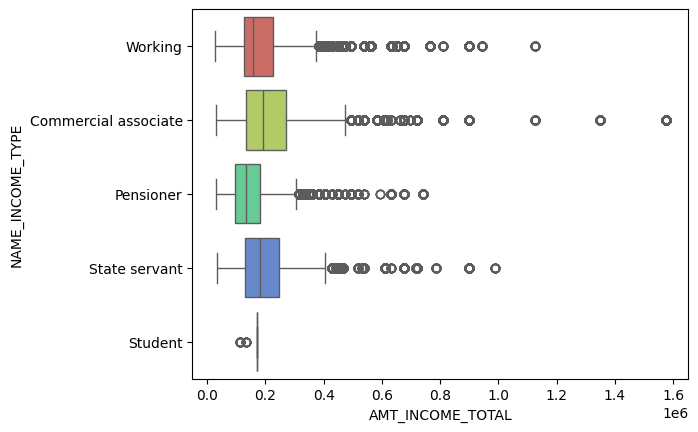

In [33]:
sb.boxplot(x='AMT_INCOME_TOTAL', y='NAME_INCOME_TYPE', hue='NAME_INCOME_TYPE', legend=False, data=tabela_final, palette='hls',)

# Agrupar colunas da tabela pela quantidade de ID para termos ideia dos valores e quantidade das variáveis.

In [34]:
tabela_final.groupby('FLAG_OWN_CAR')['ID'].count().sort_values(ascending=False).head()

,ID
FLAG_OWN_CAR,
N,473355
Y,304360


In [35]:
tabela_final.groupby('CODE_GENDER')['ID'].count().sort_values(ascending=False).head()

,ID
CODE_GENDER,
F,518851
M,258864


In [36]:
tabela_final.groupby('CNT_CHILDREN')['ID'].count().sort_values(ascending=False).head(20)

,ID
CNT_CHILDREN,
0,540639
1,155638
2,70399
3,9328
4,1224
5,324
14,111
7,46
19,6


Obs.: Na visualização acima podemos perceber que existem dois valores que não condizem com a realidade e devemos analisar. 14 e 19 filhos??

In [37]:
tabela_final.groupby('AMT_INCOME_TOTAL')['ID'].count().sort_values(ascending=False).head(1000)

,ID
AMT_INCOME_TOTAL,
135000.0,90217
180000.0,68579
157500.0,62686
112500.0,61622
225000.0,61399
...,...
51750.0,7
89550.0,5
594000.0,4


In [38]:
tabela_final.groupby('NAME_INCOME_TYPE')['ID'].count().sort_values(ascending=False).head(10)

,ID
NAME_INCOME_TYPE,
Working,400164
Commercial associate,183385
Pensioner,128392
State servant,65437
Student,337


In [39]:
tabela_final.groupby('NAME_EDUCATION_TYPE')['ID'].count().sort_values(ascending=False).head()

,ID
NAME_EDUCATION_TYPE,
Secondary / secondary special,524261
Higher education,213633
Incomplete higher,30329
Lower secondary,8655
Academic degree,837


In [40]:
tabela_final.groupby('NAME_FAMILY_STATUS')['ID'].count().sort_values(ascending=False).head()

,ID
NAME_FAMILY_STATUS,
Married,546619
Single / not married,94335
Civil marriage,60342
Separated,45255
Widow,31164


In [41]:
tabela_final.groupby('NAME_HOUSING_TYPE')['ID'].count().sort_values(ascending=False).head(10)

,ID
NAME_HOUSING_TYPE,
House / apartment,697151
With parents,35735
Municipal apartment,24640
Rented apartment,10898
Office apartment,5636
Co-op apartment,3655


In [42]:
tabela_final.groupby('DAYS_BIRTH')['ID'].count().sort_values(ascending=False).head()

,ID
DAYS_BIRTH,
-14667,1018
-15140,928
-15675,835
-15519,799
-16995,799


In [43]:
tabela_final.groupby('DAYS_EMPLOYED')['ID'].count().sort_values(ascending=False).head()

,ID
DAYS_EMPLOYED,
365243,127972
-1751,1601
-1539,1545
-401,1498
-2531,1319


Obs.: Nesta visualização podemos perceber que o primeiro valor diverge dos demais.  
Uma avaliação criteriosa deve ser feita.

In [44]:
tabela_final.groupby('FLAG_MOBIL')['ID'].count().sort_values(ascending=False).head()

,ID
FLAG_MOBIL,
1,777715


Obs.: Nessa visualização existe apenas um valor para a variável e que é para todos os clientes.  
FLAG_MOBIL 	 - Uma variável constante não ajuda o algoritmo a distinguir  
ninguém assim como a coluna ID que não acrescenta   nenhuma informação aos dados.  
Então podemos retirar da base.

In [45]:
tabela_final.groupby('FLAG_WORK_PHONE')['ID'].count().sort_values(ascending=False).head()

,ID
FLAG_WORK_PHONE,
0,597427
1,180288


In [46]:
tabela_final.groupby('FLAG_PHONE')['ID'].count().sort_values(ascending=False).head()

,ID
FLAG_PHONE,
0,543650
1,234065


In [47]:
tabela_final.groupby('FLAG_EMAIL')['ID'].count().sort_values(ascending=False).head()

,ID
FLAG_EMAIL,
0,706418
1,71297


In [48]:
tabela_final.groupby('OCCUPATION_TYPE')['ID'].count().sort_values(ascending=False).head(1000)

,ID
OCCUPATION_TYPE,
Laborers,131572
Core staff,77112
Sales staff,70362
Managers,67738
Drivers,47678
High skill tech staff,31768
Accountants,27223
Medicine staff,26691
Cooking staff,13416


Obs.: Temos que lembrar que para Occupation_type existem alguns valores nulos. OCCUPATION_TYPE tem 537.667 registros e demais colunas há 777.715 registros. Devemos analisar para vermos a possibilidade de exclusão ou tratamento.


In [49]:
tabela_final.groupby('CNT_FAM_MEMBERS')['ID'].count().sort_values(ascending=False).head(100)

,ID
CNT_FAM_MEMBERS,
2.0,423723
1.0,141477
3.0,134894
4.0,66990
5.0,8999
6.0,1196
7.0,273
15.0,111
9.0,46


In [50]:
tabela_final.groupby('MONTHS_BALANCE')['ID'].count().sort_values(ascending=False).head(100)

,ID
MONTHS_BALANCE,
-1,24963
-2,24871
0,24672
-3,24644
-4,24274
...,...
-56,1588
-57,1253
-58,955


In [51]:
resultado = tabela_final.groupby('STATUS')['ID'].agg(Quantidade='count', Percentual=lambda x: (x.count() / len(tabela_final)) * 100).sort_values(by='Quantidade', ascending=False).head(10)
resultado


,Quantidade,Percentual
STATUS,,
C,329536,42.372334
0,290654,37.372817
X,145950,18.766515
1,8747,1.124705
5,1527,0.196344
2,801,0.102994
3,286,0.036774
4,214,0.027517


In [52]:
tabela_final.groupby(['NAME_HOUSING_TYPE','STATUS'])['ID'].count().sort_values(ascending=False).head(1000)

NAME_HOUSING_TYPE    STATUS
House / apartment    C         296473
                     0         260627
                     X         129824
With parents         C          15005
                     0          13393
Municipal apartment  C          10103
                     0           9319
House / apartment    1           7758
With parents         X           6771
Municipal apartment  X           4789
Rented apartment     C           4428
                     0           4118
Office apartment     C           2199
Rented apartment     X           2180
Office apartment     0           2009
House / apartment    5           1368
Co-op apartment      C           1328
Office apartment     X           1306
Co-op apartment      0           1188
                     X           1080
House / apartment    2            683
With parents         1            461
Municipal apartment  1            280
House / apartment    3            242
                     4            176
Rented apartment     1            127
Office apartment     1             92
Municipal apartment  5             54
                     2             49
With parents         5             46
                     2             41
Co-op apartment      1             29
Rented apartment     5             29
Municipal apartment  4             25
                     3             21
Co-op apartment      5             16
Office apartment     5             14
With parents         3             12
Office apartment     2             10
Co-op apartment      2              9
Rented apartment     2              9
With parents         4              6
Rented apartment     3              4
Office apartment     3              4
Rented apartment     4              3
Co-op apartment      3              3
                     4              2
Office apartment     4              2
Name: ID, dtype: int64

In [53]:
tabela_final.groupby(['NAME_INCOME_TYPE','STATUS'])['ID'].count().sort_values(ascending=False).head(1000)

NAME_INCOME_TYPE      STATUS
Working               C         170202
                      0         148915
Commercial associate  C          76295
Working               X          75397
Commercial associate  0          69302
Pensioner             C          55355
                      0          47731
Commercial associate  X          34523
State servant         C          27484
                      0          24639
Pensioner             X          23539
State servant         X          12422
Working               1           4454
Commercial associate  1           2368
Pensioner             1           1157
State servant         1            767
Working               5            592
Commercial associate  5            561
Working               2            402
Pensioner             5            313
Student               C            200
Commercial associate  2            187
Pensioner             2            173
Working               3            112
                      4             90
Pensioner             3             80
Commercial associate  3             77
                      4             72
Student               X             69
                      0             67
State servant         5             61
Pensioner             4             44
State servant         2             39
                      3             17
                      4              8
Student               1              1
Name: ID, dtype: int64

In [54]:
tabela_final.groupby(['NAME_EDUCATION_TYPE','STATUS'])['ID'].count().sort_values(ascending=False).head(1000)

NAME_EDUCATION_TYPE            STATUS
Secondary / secondary special  C         221366
                               0         199305
                               X          96066
Higher education               C          90177
                               0          77192
                               X          43063
Incomplete higher              C          13282
                               0          11241
Secondary / secondary special  1           5828
Incomplete higher              X           5143
Lower secondary                C           4237
                               0           2708
Higher education               1           2264
Lower secondary                X           1531
Secondary / secondary special  5            871
Higher education               5            577
Incomplete higher              1            535
Secondary / secondary special  2            515
Academic degree                C            474
Higher education               2            225
Academic degree                0            208
Secondary / secondary special  3            183
Academic degree                X            147
Secondary / secondary special  4            127
Lower secondary                1            112
Higher education               3             80
                               4             55
Incomplete higher              2             47
Lower secondary                5             40
Incomplete higher              5             39
                               4             24
                               3             18
Lower secondary                2             14
Academic degree                1              8
Lower secondary                4              8
                               3              5
Name: ID, dtype: int64

In [55]:
tabela_final.groupby(['NAME_FAMILY_STATUS','STATUS'])['ID'].count().sort_values(ascending=False).head(1000)

NAME_FAMILY_STATUS    STATUS
Married               C         231084
                      0         204691
                      X         102981
Single / not married  C          41009
                      0          35570
Civil marriage        C          26105
                      0          21671
Separated             C          18877
                      0          16595
Single / not married  X          16032
Widow                 C          12461
                      0          12127
Civil marriage        X          11682
Separated             X           9119
Widow                 X           6136
Married               1           5910
Single / not married  1           1276
Married               5           1139
Civil marriage        1            778
Married               2            497
Separated             1            493
Widow                 1            290
Single / not married  5            213
Married               3            181
Single / not married  2            141
Married               4            136
Separated             5             73
Widow                 5             69
Civil marriage        2             60
Widow                 2             55
Single / not married  3             50
Separated             2             48
Single / not married  4             44
Civil marriage        5             33
Separated             3             29
                      4             21
Widow                 3             18
Civil marriage        3              8
Widow                 4              8
Civil marriage        4              5
Name: ID, dtype: int64

In [56]:
tabela_final.groupby(['OCCUPATION_TYPE','STATUS'])['ID'].count().sort_values(ascending=False).head(1000)

OCCUPATION_TYPE       STATUS
Laborers              C         56747
                      0         47681
Core staff            C         32043
Sales staff           C         29874
Core staff            0         28670
                                ...  
Low-skill Laborers    3             2
Waiters/barmen staff  2             2
Secretaries           5             2
HR staff              2             1
Waiters/barmen staff  3             1
Name: ID, Length: 130, dtype: int64

#Estudos iniciais para determinação da variável target (alvo)

In [57]:
#Criar a variável Target pois com a base de dados obtida não conseguimos identificar bons e maus pagadores.
#Vamos considerar mal pagador aqueles que tiverem mais de 29 dias de atraso.
#Perfil de Crédito = Bom pagador = 0 (Status 0) e Mau pagador = 1 (Status 1,2,3,4,5)

def definir_variavel_target(status_cliente):

    status = set(status_cliente)

    # Mau pagador: algum atraso >= 30 dias
    if status.intersection({'1', '2', '3', '4', '5'}):
        return 1

    # Bom pagador: possui histórico e nunca chegou a 30 dias
    elif status.intersection({'C', '0'}):
        return 0

    # Somente X: não existe histórico suficiente
    else:
        return None

In [58]:
target_por_cliente = (
    tabela_final.groupby('ID')['STATUS']
      .apply(definir_variavel_target)
      .reset_index(name='Perfil de Crédito')
)

In [59]:
# Criar uma única linha por cliente
tabela_final_target = (
    tabela_final.drop(columns=['MONTHS_BALANCE', 'STATUS'])
      .drop_duplicates(subset='ID'))

Obs.: Não incluirei MONTHS_BALANCE e STATUS nesse primeiro modelo. Eles já cumpriram sua função na construção do comportamento do cliente. Será considerado "mau pagador" aqueles que tiverem mais de 30 dias de atraso independente de ter tido ou não em outros tempos.

In [60]:
tabela_final = tabela_final_target.merge(
    target_por_cliente,
    on='ID',
    how='left'
)

In [61]:
# Remover clientes sem histórico de crédito
tabela_final = tabela_final.dropna(subset=['Perfil de Crédito'])

# Converter TARGET para inteiro
tabela_final['Perfil de Crédito'] = tabela_final['Perfil de Crédito'].astype(int)


# Conferir resultado
print(tabela_final[['ID', 'Perfil de Crédito']].head(20))

print(tabela_final['Perfil de Crédito'].value_counts())
print(tabela_final['Perfil de Crédito'].value_counts(normalize=True).mul(100).round(2))
print(

)

         ID  Perfil de Crédito
0   5008804                  1
1   5008805                  1
2   5008806                  0
3   5008808                  0
5   5008810                  0
6   5008811                  0
7   5008812                  0
8   5008813                  0
9   5008814                  0
10  5008815                  0
11  5112956                  0
13  5008820                  0
14  5008821                  0
15  5008822                  0
16  5008823                  0
17  5008824                  0
18  5008825                  1
19  5008826                  1
20  5008830                  1
21  5008831                  1
Perfil de Crédito
0    28819
1     4291
Name: count, dtype: int64
Perfil de Crédito
0    87.04
1    12.96
Name: proportion, dtype: float64



In [62]:
tabela_final.head(10)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Perfil de Crédito
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,0
10,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,1,Accountants,2.0,0


#**Matriz de correlação**  
Devemos selecionar apenas as colunas numéricas contínuas ou discretas, pois o cálculo padrão (como o coeficiente de Pearson) exige dados quantitativos
para medir a força e a direção de uma relação linear.  



(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 0, 'CNT_CHILDREN'),
  Text(1.5, 0, 'AMT_INCOME_TOTAL'),
  Text(2.5, 0, 'DAYS_BIRTH'),
  Text(3.5, 0, 'DAYS_EMPLOYED'),
  Text(4.5, 0, 'FLAG_WORK_PHONE'),
  Text(5.5, 0, 'FLAG_PHONE'),
  Text(6.5, 0, 'FLAG_EMAIL'),
  Text(7.5, 0, 'CNT_FAM_MEMBERS')])

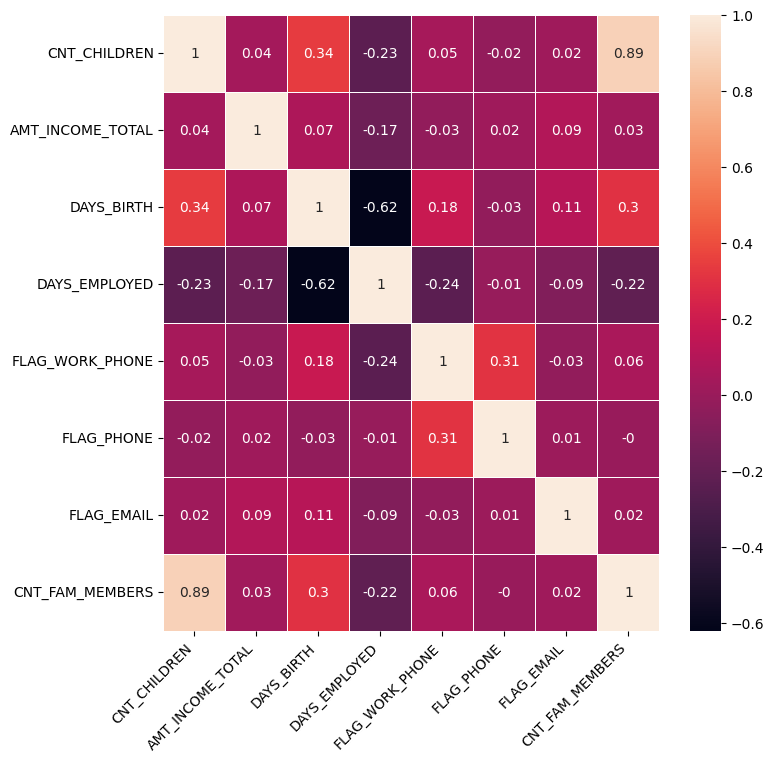

In [63]:
#Matriz de correlação

import matplotlib.pyplot as plt

tabela_cor = tabela_final[['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED','FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',  'CNT_FAM_MEMBERS']]
correlation_matrix = tabela_cor.corr().round(2)

fig, ax = plt.subplots(figsize=(8,8))
sb.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)
plt.xticks(rotation=45, ha='right')

Obs.: Um coeficiente de correlação linear maior que zero indica uma relação positiva. Um valor menor que zero indica uma relação negativa. Por fim, um valor igual a zero indica que não há relação entre as duas variáveis.

#**Preparação das variáveis pessoais/financeiras**

Como uma visão geral da base vamos começar a verificar nulos, valores anômalos, transformar DAYS_BIRTH em idade,DAYS_EMPLOYED em tempo de emprego e codificar as categóricas.

Vamos tratar também OCCUPATION_TYPE pois a ausência da profissão pode conter informação preditiva.  
Por exemplo, pensionistas ou pessoas fora do mercado formal podem aparecer mais frequentemente sem ocupação declarada.

In [64]:
#Identificar informações destes que possuem OCCUPATION_TYPE nula para ver se podemos excluir da base ou colocar que não foi informada
tabela_final.query('OCCUPATION_TYPE.isnull()', engine='python')

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Perfil de Crédito
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36439,5148602,M,N,Y,0,225000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22946,365243,1,0,0,0,NaN,2.0,1
36440,5148679,F,N,N,0,121500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18828,-6195,1,0,0,0,NaN,2.0,1
36445,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15837,-2694,1,1,1,0,NaN,2.0,1
36446,5149056,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15837,-2694,1,1,1,0,NaN,2.0,1


In [65]:
#Verificado que não podemos excluir, tem informações que serão necessárias para os estudos.
tabela_final['OCCUPATION_TYPE'] = tabela_final['OCCUPATION_TYPE'].fillna('Não informado')

In [66]:
# A única quantidade de dias positivos é 365243, o que pode sinalizar algo com relação ao tempo de serviço.
#Encontramos um total de 127972 clientes com essa quantidade de dias. Bem expressivo
# Vamos analisar as linhas que contenham esse valor

DAYS_EMPLOYED_Analise = tabela_final.query("DAYS_EMPLOYED == 365243")
DAYS_EMPLOYED_Analise['NAME_INCOME_TYPE'].unique()

array(['Pensioner'], dtype=object)

Obtivemos como resultado da análise acima apenas Pensioner (Pensionista/Aposentados).
Como a quantidade é bem expressiva não podemos simplesmente retirar da base.
Vamos apartar em uma outra coluna,Pensionista, para separar dos que estão em atividade.


In [67]:
tabela_final['PENSIONISTA'] = (
    tabela_final['DAYS_EMPLOYED'] == 365243
).astype(int)

Agora para criarmos a coluna Tempo_serviço, precisamos "excluir" os valores dos pensionistas para não impactar do modelo. Criada a coluna Pensionista para não perdermos a informação.

In [68]:
# função para converter número em anos e dias.
def converter_ano_decimal(dias):
    dias_positivos = abs(dias)

    # Calcula os anos inteiros e o resto em dias
    anos_inteiros = dias_positivos // 365
    resto_dias = dias_positivos % 365

    # Transforma o resto de dias em fração decimal de um ano (365 dias)
    ano_decimal = anos_inteiros + (resto_dias / 365)

    # Arredonda para 1 casa decimal
    return round(ano_decimal, 1)


In [69]:
# Substituir o código 365243, referente aos pensionistas,por valor ausente e calcular o tempo de serviço em anos

tabela_final['Tempo_Serviço'] = (
    tabela_final['DAYS_EMPLOYED']
    .replace(365243, np.nan)
    .apply(
        lambda x: converter_ano_decimal(x)
        if pd.notna(x)
        else np.nan
    )
)

A variável Tempo_Serviço foi construída diretamente a partir de DAYS_EMPLOYED, preservando os índices do DataFrame. O código 365243, identificado exclusivamente em pensionistas, foi convertido em valor ausente, mantendo-se a informação de pensionista em variável específica. Após a correção, os 5.642 valores ausentes de Tempo_Serviço correspondem exclusivamente aos pensionistas.

In [70]:
print("Total de registros:", len(tabela_final))

print(
    "DAYS_EMPLOYED = 365243:",
    (tabela_final['DAYS_EMPLOYED'] == 365243).sum()
)

print(
    "Nulos em Tempo_Serviço:",
    tabela_final['Tempo_Serviço'].isna().sum()
)

print(
    "Nulos em Tempo_Serviço entre não pensionistas:",
    tabela_final.loc[
        tabela_final['DAYS_EMPLOYED'] != 365243,
        'Tempo_Serviço'
    ].isna().sum()
)

Total de registros: 33110
DAYS_EMPLOYED = 365243: 5642
Nulos em Tempo_Serviço: 5642
Nulos em Tempo_Serviço entre não pensionistas: 0


In [71]:
tabela_final[
    ['ID', 'DAYS_EMPLOYED', 'PENSIONISTA', 'Tempo_Serviço']
].head(20)

,ID,DAYS_EMPLOYED,PENSIONISTA,Tempo_Serviço
0,5008804,-4542,0,12.4
1,5008805,-4542,0,12.4
2,5008806,-1134,0,3.1
3,5008808,-3051,0,8.4
5,5008810,-3051,0,8.4
6,5008811,-3051,0,8.4
7,5008812,365243,1,NaN
8,5008813,365243,1,NaN
9,5008814,365243,1,NaN
10,5008815,-769,0,2.1


In [72]:
print("Total de registros:", len(tabela_final))

print(
    "Pensionistas / DAYS_EMPLOYED = 365243:",
    (tabela_final['DAYS_EMPLOYED'] == 365243).sum()
)

print(
    "Nulos em Tempo_Serviço:",
    tabela_final['Tempo_Serviço'].isna().sum()
)

print(
    "Nulos entre não pensionistas:",
    tabela_final.loc[
        tabela_final['DAYS_EMPLOYED'] != 365243,
        'Tempo_Serviço'
    ].isna().sum()
)

Total de registros: 33110
Pensionistas / DAYS_EMPLOYED = 365243: 5642
Nulos em Tempo_Serviço: 5642
Nulos entre não pensionistas: 0


In [73]:
#Criar colunas de Idade do cliente
tabela_final['Idade'] = tabela_final['DAYS_BIRTH'].apply(converter_ano_decimal)

#Renda — AMT_INCOME_TOTAL  
Análise da distribuição da variável. Com valor original nos gráficos, ele deixa os outliers evidentes.

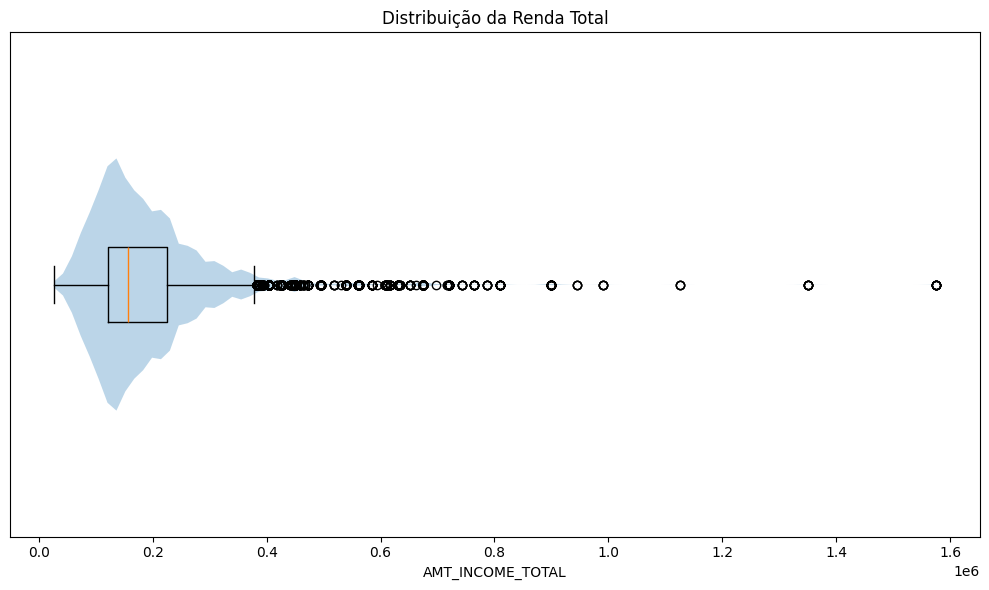

In [74]:
import matplotlib.pyplot as plt

dados = tabela_final['AMT_INCOME_TOTAL'].dropna()

plt.figure(figsize=(10, 6))

# Violin plot
plt.violinplot(
    dados,
    vert=False,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Box plot sobreposto
plt.boxplot(
    dados,
    vert=False,
    widths=0.15,
    showfliers=True
)

plt.title('Distribuição da Renda Total')
plt.xlabel('AMT_INCOME_TOTAL')
plt.yticks([])

plt.tight_layout()
plt.show()


Visualizamos uma longa cauda à direita mostrando que há uma distribuição bastante assimétrica (mediana ≈ 157.500
máximo = 1.575.000).



#Vou usar a função logaritma para deixar a distribuição muito mais equilibrada.

In [75]:
tabela_final['LOG_RENDA'] = np.log1p(
    tabela_final['AMT_INCOME_TOTAL']
)

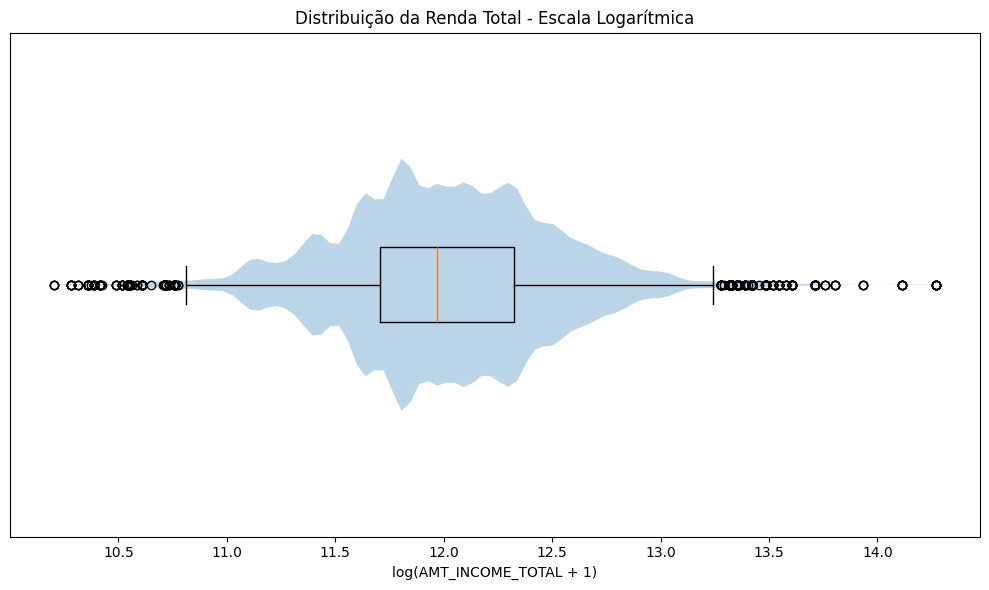

In [76]:
dados_log = np.log1p(
    tabela_final['AMT_INCOME_TOTAL'].dropna()
)

plt.figure(figsize=(10, 6))

plt.violinplot(
    dados_log,
    vert=False,
    showextrema=False
)

plt.boxplot(
    dados_log,
    vert=False,
    widths=0.15,
    showfliers=True
)

plt.title('Distribuição da Renda Total - Escala Logarítmica')
plt.xlabel('log(AMT_INCOME_TOTAL + 1)')
plt.yticks([])

plt.tight_layout()
plt.show()

A variável AMT_INCOME_TOTAL apresentou valores extremos e elevada assimetria em sua distribuição original. Dessa forma, foi aplicada uma transformação pelo logaritmo natural, com o objetivo de reduzir a influência de observações extremas e tornar a distribuição mais equilibrada. A análise conjunta do violin plot e do box plot após a transformação evidencia maior concentração das observações em torno da região central, embora permaneçam alguns outliers nas extremidades. A transformação preserva a ordenação dos valores de renda, ao mesmo tempo que reduz as diferenças relativas entre rendas muito elevadas e as demais observações, tornando a variável mais adequada para utilização nos modelos de classificação.

In [77]:
#para saber quanto vale o valor 12 no gráfico acima, reversão da função logaritma.
np.expm1(12)

np.float64(162753.79141900392)

Agora vou fazer dois gráficos com LOG_RENDA, um para Perfil de Crédito e = 0 e outro para Perfil de Crédito = 1. Para identificarmos se a distribuição de renda realmente difere entre bons e maus pagadores — isto é, se essa variável tem potencial discriminatório para o nosso modelo.

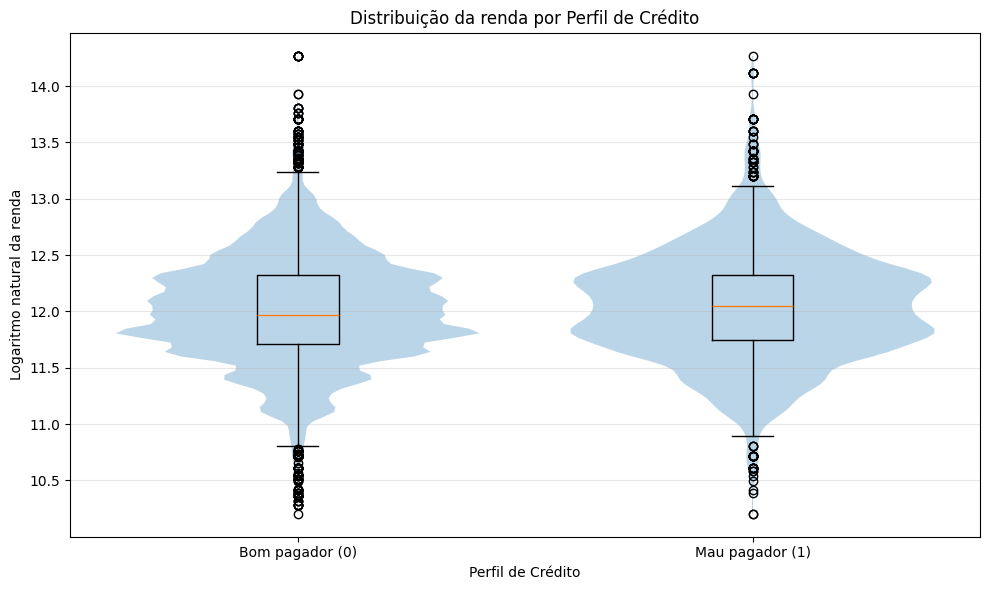

In [78]:
import matplotlib.pyplot as plt

# Separar os grupos
bom = tabela_final.loc[
    tabela_final['Perfil de Crédito'] == 0,
    'LOG_RENDA'
].dropna()

mau = tabela_final.loc[
    tabela_final['Perfil de Crédito'] == 1,
    'LOG_RENDA'
].dropna()

dados = [bom, mau]

plt.figure(figsize=(10, 6))

# Violin plots
plt.violinplot(
    dados,
    positions=[1, 2],
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Boxplots sobrepostos
plt.boxplot(
    dados,
    positions=[1, 2],
    widths=0.18,
    showfliers=True
)

plt.xticks(
    [1, 2],
    ['Bom pagador (0)', 'Mau pagador (1)']
)

plt.ylabel('Logaritmo natural da renda')
plt.xlabel('Perfil de Crédito')

plt.title(
    'Distribuição da renda por Perfil de Crédito'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [79]:
resumo_renda = (
    tabela_final
    .groupby('Perfil de Crédito')['LOG_RENDA']
    .agg(['count', 'mean', 'median', 'std'])
)

print(resumo_renda)

                   count       mean     median       std
Perfil de Crédito                                       
0                  28819  12.010448  11.967187  0.477430
1                   4291  12.043382  12.049425  0.495301


Conclusão: A análise da renda transformada pelo logaritmo natural mostrou distribuições bastante semelhantes entre bons e maus pagadores. O grupo classificado como mau pagador apresentou média e mediana ligeiramente superiores às do grupo de bons pagadores, porém a diferença é pequena quando comparada à dispersão observada. Esse resultado sugere que a renda, considerada isoladamente, possui baixo poder discriminatório para identificar o risco de inadimplência, embora possa contribuir para o modelo quando combinada com outras características dos solicitantes.

# Análise das variáveis CNT_CHILDREN e CNT_FAM_MEMBERS.

Não sabemos se são erros ou famílias realmente grandes.
Então não vou excluir, apenas agrupar.  Definir um "teto" ajuda a estabilizar os dados.
Criaremos uma coluna com valores de 0 a 5, onde 5 representa aqueles que tiverem cinco ou mais filhos.
A mesma lógica usaremos para membros da família.



In [80]:
# -------------------------
# FILHOS
# 5 = cinco ou mais
# -------------------------

tabela_final['QTD_FILHOS'] = (
    tabela_final['CNT_CHILDREN']
    .clip(upper=5)
)

# -------------------------
# FAMÍLIA
# 8 = oito ou mais
# -------------------------

tabela_final['QTD_FAMILIARES'] = (
    tabela_final['CNT_FAM_MEMBERS'].clip(upper=8)
                                         )

Uma outra feature que podemos criar é a de renda por membro da família ('AMT_INCOME_TOTAL'/'CNT_FAM_MEMBERS') pois
duas pessoas podem ter a mesma renda porém a capacidade financeira não é exatamente a mesma.

In [81]:
import numpy as np

tabela_final = tabela_final.copy()

# -------------------------
# RENDA PER CAPITA
# -------------------------

tabela_final['RENDA_PER_CAPITA'] = (
    tabela_final['AMT_INCOME_TOTAL'] /
    tabela_final['CNT_FAM_MEMBERS']
)

# usar a função logaritma para deixar a distribuição mais equilibrada
tabela_final['LOG_RENDA_PER_CAPITA'] = np.log1p(
    tabela_final['RENDA_PER_CAPITA']
)

In [82]:
# ------------------------------------------------------------------------
# FAZER DROP DE COLUNAS ORIGINAIS E CRIADAS QUE NÃO SERÃO MAIS NECESSÁRIAS. FAZER LIMPEZA DA BASE.
# ------------------------------------------------------------------------

tabela_final.drop(
    columns=[
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'AMT_INCOME_TOTAL',
        'RENDA_PER_CAPITA',
        'CNT_CHILDREN',
        'CNT_FAM_MEMBERS',
        'FLAG_MOBIL'
    ],
    inplace=True
)

In [83]:
#Tabela após transformação em algumas colunas e drop de outras
tabela_final.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,Perfil de Crédito,PENSIONISTA,Tempo_Serviço,Idade,LOG_RENDA,QTD_FILHOS,QTD_FAMILIARES,LOG_RENDA_PER_CAPITA
0,5008804,M,Y,Y,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Não informado,1,0,12.4,32.9,12.965712,0,2.0,12.272567
1,5008805,M,Y,Y,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Não informado,1,0,12.4,32.9,12.965712,0,2.0,12.272567
2,5008806,M,Y,Y,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,0,0,3.1,58.8,11.630717,0,2.0,10.937579
3,5008808,F,N,Y,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,0,8.4,52.4,12.506181,0,1.0,12.506181
5,5008810,F,N,Y,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,0,8.4,52.4,12.506181,0,1.0,12.506181



No entanto, a base atual ainda requer ajustes antes da aplicação de modelos de Machine Learning. É necessário realizar transformações adicionais, como a criação de variáveis dummy (ou binarização de variáveis).



#Transformações

#Variáveis binárias

Podemos transformá-las diretamente em 0 e 1. Isso é perfeitamente adequado porque há apenas duas categorias.

In [84]:
tabela_final['CODE_GENDER'] = tabela_final['CODE_GENDER'].map({
    'F': 0,
    'M': 1
})

tabela_final['FLAG_OWN_CAR'] = tabela_final['FLAG_OWN_CAR'].map({
    'N': 0,
    'Y': 1
})

tabela_final['FLAG_OWN_REALTY'] = tabela_final['FLAG_OWN_REALTY'].map({
    'N': 0,
    'Y': 1
})

In [85]:
tabela_final.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,Perfil de Crédito,PENSIONISTA,Tempo_Serviço,Idade,LOG_RENDA,QTD_FILHOS,QTD_FAMILIARES,LOG_RENDA_PER_CAPITA
0,5008804,1,1,1,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Não informado,1,0,12.4,32.9,12.965712,0,2.0,12.272567
1,5008805,1,1,1,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Não informado,1,0,12.4,32.9,12.965712,0,2.0,12.272567
2,5008806,1,1,1,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,0,0,3.1,58.8,11.630717,0,2.0,10.937579
3,5008808,0,0,1,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,0,8.4,52.4,12.506181,0,1.0,12.506181
5,5008810,0,0,1,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,0,8.4,52.4,12.506181,0,1.0,12.506181


In [86]:
tabela_final.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
ID,33110.0,5078014.66,41876.79,5008804.00,5041983.25,5069441.00,5114632.75,5150487.00
CODE_GENDER,33110.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00
FLAG_OWN_CAR,33110.0,0.38,0.48,0.00,0.00,0.00,1.00,1.00
FLAG_OWN_REALTY,33110.0,0.67,0.47,0.00,0.00,1.00,1.00,1.00
FLAG_WORK_PHONE,33110.0,0.22,0.42,0.00,0.00,0.00,0.00,1.00
FLAG_PHONE,33110.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00
FLAG_EMAIL,33110.0,0.09,0.29,0.00,0.00,0.00,0.00,1.00
Perfil de Crédito,33110.0,0.13,0.34,0.00,0.00,0.00,0.00,1.00
PENSIONISTA,33110.0,0.17,0.38,0.00,0.00,0.00,0.00,1.00
Tempo_Serviço,27468.0,7.29,6.49,0.00,2.70,5.50,9.60,43.00


In [87]:
print(tabela_final.shape)
print(tabela_final.info())

print("\nValores ausentes:")
print(
    tabela_final.isnull()
    .sum()
    .sort_values(ascending=False)
)

(33110, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 33110 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    33110 non-null  int64  
 1   CODE_GENDER           33110 non-null  int64  
 2   FLAG_OWN_CAR          33110 non-null  int64  
 3   FLAG_OWN_REALTY       33110 non-null  int64  
 4   NAME_INCOME_TYPE      33110 non-null  object 
 5   NAME_EDUCATION_TYPE   33110 non-null  object 
 6   NAME_FAMILY_STATUS    33110 non-null  object 
 7   NAME_HOUSING_TYPE     33110 non-null  object 
 8   FLAG_WORK_PHONE       33110 non-null  int64  
 9   FLAG_PHONE            33110 non-null  int64  
 10  FLAG_EMAIL            33110 non-null  int64  
 11  OCCUPATION_TYPE       33110 non-null  object 
 12  Perfil de Crédito     33110 non-null  int64  
 13  PENSIONISTA           33110 non-null  int64  
 14  Tempo_Serviço         27468 non-null  float64
 15  Idade       

In [88]:
tabela_final = (
    tabela_final
    .drop_duplicates(subset='ID')
    .reset_index(drop=True)
)

In [89]:
print(tabela_final.shape)

print(
    "IDs únicos:",
    tabela_final['ID'].nunique()
)

(33110, 20)
IDs únicos: 33110


In [90]:
print(tabela_final.columns.tolist())

['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'Perfil de Crédito', 'PENSIONISTA', 'Tempo_Serviço', 'Idade', 'LOG_RENDA', 'QTD_FILHOS', 'QTD_FAMILIARES', 'LOG_RENDA_PER_CAPITA']


In [91]:
print(
    tabela_final['Perfil de Crédito']
    .value_counts(dropna=False)
)

Perfil de Crédito
0    28819
1     4291
Name: count, dtype: int64


In [92]:
print(tabela_final['Perfil de Crédito'].value_counts(dropna=False, normalize=True) * 100)

Perfil de Crédito
0    87.040169
1    12.959831
Name: proportion, dtype: float64


In [93]:
tabela_final = (
    tabela_final
    .dropna(subset=['Perfil de Crédito'])
)

tabela_final['Perfil de Crédito'] = (
    tabela_final['Perfil de Crédito'].astype(int)
)

In [94]:
tabela_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33110 entries, 0 to 33109
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    33110 non-null  int64  
 1   CODE_GENDER           33110 non-null  int64  
 2   FLAG_OWN_CAR          33110 non-null  int64  
 3   FLAG_OWN_REALTY       33110 non-null  int64  
 4   NAME_INCOME_TYPE      33110 non-null  object 
 5   NAME_EDUCATION_TYPE   33110 non-null  object 
 6   NAME_FAMILY_STATUS    33110 non-null  object 
 7   NAME_HOUSING_TYPE     33110 non-null  object 
 8   FLAG_WORK_PHONE       33110 non-null  int64  
 9   FLAG_PHONE            33110 non-null  int64  
 10  FLAG_EMAIL            33110 non-null  int64  
 11  OCCUPATION_TYPE       33110 non-null  object 
 12  Perfil de Crédito     33110 non-null  int64  
 13  PENSIONISTA           33110 non-null  int64  
 14  Tempo_Serviço         27468 non-null  float64
 15  Idade              

# Separar X e y

A variável que queremos prever é: Perfil de Crédito

In [95]:
X = tabela_final.drop(
    columns=['ID', 'Perfil de Crédito']
)

y = tabela_final['Perfil de Crédito']

**Confira**
Devemos continuar observando aproximadamente:

0 ≈ 87%
1 ≈ 13%

In [96]:
print(X.shape)
print(y.shape)

print(y.value_counts())
print(y.value_counts(normalize=True))

(33110, 18)
(33110,)
Perfil de Crédito
0    28819
1     4291
Name: count, dtype: int64
Perfil de Crédito
0    0.870402
1    0.129598
Name: proportion, dtype: float64


# Separar treino e teste



In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=142,
    stratify=y
)

In [98]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

colunas_categoricas = [
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

colunas_numericas = [
    coluna for coluna in X_train.columns
    if coluna not in colunas_categoricas
]

In [99]:
pipeline_categorico = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='constant',
            fill_value='Não informado'
        )
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

In [100]:
pipeline_numerico = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    )
])

In [101]:
preprocessor = ColumnTransformer([
    (
        'num',
        pipeline_numerico,
        colunas_numericas
    ),
    (
        'cat',
        pipeline_categorico,
        colunas_categoricas
    )
])

In [102]:
print(X_train.shape)
print(X_test.shape)

(26488, 18)
(6622, 18)


In [103]:
print(
    X_train.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()
)

['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


In [104]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identificar as colunas automaticamente
colunas_categoricas = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

colunas_numericas = X_train.select_dtypes(
    exclude=['object', 'category']
).columns.tolist()

print("Categóricas:", len(colunas_categoricas))
print("Numéricas:", len(colunas_numericas))
print("Total:", len(colunas_categoricas) + len(colunas_numericas))

Categóricas: 5
Numéricas: 13
Total: 18


In [105]:
pipeline_categorico = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='constant',
            fill_value='Não informado'
        )
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

In [106]:
pipeline_numerico_rf = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    )
])

preprocessor_rf = ColumnTransformer([
    (
        'num',
        pipeline_numerico_rf,
        colunas_numericas
    ),
    (
        'cat',
        pipeline_categorico,
        colunas_categoricas
    )
])

In [107]:
pipeline_numerico_escalado = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

preprocessor_escalado = ColumnTransformer([
    (
        'num',
        pipeline_numerico_escalado,
        colunas_numericas
    ),
    (
        'cat',
        pipeline_categorico,
        colunas_categoricas
    )
])

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

modelo_logistico = Pipeline([
    (
        'preprocessor',
        preprocessor_escalado
    ),
    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

#Treinar

In [109]:
modelo_logistico.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'PENSIONISTA',
                                                   'Tempo_Serviço', 'Idade',
                                                   'LOG_RENDA', 'QTD_FILHOS',
                                                   'QTD_FAMILIARES',
                                                   'LOG_RENDA_PER_CAPITA']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Não '
                                                                                            'informado',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

# Métrica ROC-AUC

In [110]:
#ROC-AUC - Vamos também avaliar probabilidades, e não somente a classificação 0/1
y_prob = modelo_logistico.predict_proba(
    X_test
)[:, 1]


A métrica ROC-AUC nos mostra a capacidade do modelo de ordenar clientes de maior e menor risco, independentemente do corte padrão de 50%.  
Uma interpretação rápida  
0,50 → praticamente aleatório  
0,60 → fraco  
0,70 → razoável  
0,80 → bom  
0,90+ → excelente

In [111]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.5451


Obs.: o modelo consegue ordenar praticamente aleatório clientes de maior e menor risco. Em termos intuitivos, ao comparar aleatoriamente um bom e um mau pagador, o modelo atribui maior risco ao mau pagador em cerca de 54% dos pares.

# Métrica PR-AUC

In [112]:
#PR-AUC é ainda mais interessante - Como temos classe desbalanceada.
#O PR-AUC foca mais diretamente na qualidade da detecção da classe positiva (1).
#PR-AUC prioriza a precisão (quantos previstos positivos são realmente positivos)
# e o recall (quantos positivos reais foram detectados),
#concentrando-se diretamente na classe rara ou de maior interesse.
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test,
    y_prob
)

print(
    "PR-AUC:",
    round(pr_auc, 4)
)

PR-AUC: 0.1647


Obs.: O modelo apresenta capacidade limitada para identificar maus pagadores. Embora sua PR-AUC de 0,1647 seja superior à prevalência da classe positiva, aproximadamente 0,13, a diferença é pequena, indicando baixo poder discriminatório sobre a classe minoritária.

# Agora vamos repetir os testes com balanceamento.  
Acrescentar **class_weight='balanced'** no código do pipeline.

o algoritmo passa a penalizar mais fortemente os erros cometidos com a classe minoritária, considerando importante identificar maus pagadores e não apenas acertar bons pagadores.

In [113]:
modelo_logistico_balanceado = Pipeline([
    (
        'preprocessor',
        preprocessor_escalado
    ),
    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight='balanced'
        )
    )
])

In [114]:
#Treine novamente
modelo_logistico_balanceado.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'PENSIONISTA',
                                                   'Tempo_Serviço', 'Idade',
                                                   'LOG_RENDA', 'QTD_FILHOS',
                                                   'QTD_FAMILIARES',
                                                   'LOG_RENDA_PER_C...']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Não '
                                                                                            'informado',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [115]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# KNN
modelo_knn = Pipeline([
    ('preprocessor', preprocessor_escalado),
    ('classifier',
     KNeighborsClassifier(
         n_neighbors=8,
         metric='euclidean',
         weights='distance'
     ))
])

# SVM
modelo_svm = Pipeline([
    ('preprocessor', preprocessor_escalado),
    ('classifier',
     SVC(
         class_weight='balanced',
         probability=True,
         random_state=42
     ))
])

# Random Forest
modelo_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier',
     RandomForestClassifier(
         n_estimators=100,
         class_weight='balanced',
         random_state=42,
         n_jobs=-1
     ))
])

#Validação Cruzada Estratificada




In [116]:
def AplicaValidacaoCruzada(X, y):

    import pandas as pd

    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.svm import SVC
    from sklearn.linear_model import LogisticRegression

    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.impute import SimpleImputer

    from sklearn.model_selection import (
        StratifiedKFold,
        cross_validate
    )

    from sklearn.metrics import (
        make_scorer,
        precision_score,
        recall_score,
        f1_score
    )

    # -------------------------------------------------
    # IDENTIFICAÇÃO DAS VARIÁVEIS
    # -------------------------------------------------

    colunas_categoricas = X.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()

    colunas_numericas = X.select_dtypes(
        exclude=['object', 'category']
    ).columns.tolist()


    # -------------------------------------------------
    # PIPELINE CATEGÓRICO
    # -------------------------------------------------

    pipeline_categorico = Pipeline([
        (
            'imputer',
            SimpleImputer(
                strategy='constant',
                fill_value='Não informado'
            )
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ])


    # -------------------------------------------------
    # PIPELINE NUMÉRICO COM PADRONIZAÇÃO
    # LR, KNN e SVM
    # -------------------------------------------------

    pipeline_numerico_escalado = Pipeline([
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ])


    preprocessor_escalado = ColumnTransformer([
        (
            'num',
            pipeline_numerico_escalado,
            colunas_numericas
        ),
        (
            'cat',
            pipeline_categorico,
            colunas_categoricas
        )
    ])


    # -------------------------------------------------
    # PIPELINE NUMÉRICO SEM PADRONIZAÇÃO
    # RANDOM FOREST
    # -------------------------------------------------

    pipeline_numerico_rf = Pipeline([
        (
            'imputer',
            SimpleImputer(strategy='median')
        )
    ])


    preprocessor_rf = ColumnTransformer([
        (
            'num',
            pipeline_numerico_rf,
            colunas_numericas
        ),
        (
            'cat',
            pipeline_categorico,
            colunas_categoricas
        )
    ])


    # -------------------------------------------------
    # MODELOS
    # -------------------------------------------------

    lr = Pipeline([
        (
            'preprocessor',
            preprocessor_escalado
        ),
        (
            'modelo',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                random_state=42
            )
        )
    ])


    knn = Pipeline([
        (
            'preprocessor',
            preprocessor_escalado
        ),
        (
            'modelo',
            KNeighborsClassifier(
                n_neighbors=8,
                metric='euclidean',
                weights='distance'
            )
        )
    ])


    svm = Pipeline([
        (
            'preprocessor',
            preprocessor_escalado
        ),
        (
            'modelo',
            SVC(
                class_weight='balanced',
                probability=False,
                random_state=42
            )
        )
    ])


    rf = Pipeline([
        (
            'preprocessor',
            preprocessor_rf
        ),
        (
            'modelo',
            RandomForestClassifier(
                n_estimators=100,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
    ])


    modelos = {
        'KNN': knn,
        'SVM': svm,
        'Random Forest': rf,
        'Regressão Logística': lr
    }


    # -------------------------------------------------
    # VALIDAÇÃO CRUZADA ESTRATIFICADA
    # -------------------------------------------------

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )


    # -------------------------------------------------
    # MÉTRICAS
    # -------------------------------------------------

    metricas = {
        'accuracy': 'accuracy',
        'balanced_accuracy': 'balanced_accuracy',

        'precision_1': make_scorer(
            precision_score,
            pos_label=1,
            zero_division=0
        ),

        'recall_1': make_scorer(
            recall_score,
            pos_label=1
        ),

        'f1_1': make_scorer(
            f1_score,
            pos_label=1
        ),

        'roc_auc': 'roc_auc',

        'pr_auc': 'average_precision'
    }


    # -------------------------------------------------
    # CROSS VALIDATION
    # -------------------------------------------------

    resultados = []

    for nome, modelo in modelos.items():

        resultado = cross_validate(
            modelo,
            X,
            y,
            cv=cv,
            scoring=metricas,
            n_jobs=-1
        )

        resultados.append({

            'Modelo': nome,

            'Accuracy':
                resultado['test_accuracy'].mean(),

            'Accuracy_std':
                resultado['test_accuracy'].std(),

            'Balanced Accuracy':
                resultado['test_balanced_accuracy'].mean(),

            'Balanced Accuracy_std':
                resultado['test_balanced_accuracy'].std(),

            'Precision_1':
                resultado['test_precision_1'].mean(),

            'Precision_1_std':
                resultado['test_precision_1'].std(),

            'Recall_1':
                resultado['test_recall_1'].mean(),

            'Recall_1_std':
                resultado['test_recall_1'].std(),

            'F1_1':
                resultado['test_f1_1'].mean(),

            'F1_1_std':
                resultado['test_f1_1'].std(),

            'ROC-AUC':
                resultado['test_roc_auc'].mean(),

            'ROC-AUC_std':
                resultado['test_roc_auc'].std(),

            'PR-AUC':
                resultado['test_pr_auc'].mean(),

            'PR-AUC_std':
                resultado['test_pr_auc'].std()
        })


    resultados_df = pd.DataFrame(resultados)

    return resultados_df

In [117]:
resultado_cv = AplicaValidacaoCruzada(
    X_train,
    y_train
)

resultado_cv.round(4)

,Modelo,Accuracy,Accuracy_std,Balanced Accuracy,Balanced Accuracy_std,Precision_1,Precision_1_std,Recall_1,Recall_1_std,F1_1,F1_1_std,ROC-AUC,ROC-AUC_std,PR-AUC,PR-AUC_std
0,KNN,0.8745,0.0029,0.6288,0.0063,0.5290,0.0207,0.2971,0.0130,0.3803,0.0134,0.7456,0.0076,0.3626,0.0102
1,SVM,0.6662,0.0051,0.6125,0.0051,0.2033,0.0015,0.5401,0.0185,0.2954,0.0042,0.6548,0.0097,0.2258,0.0090
2,Random Forest,0.8383,0.0076,0.6908,0.0095,0.4001,0.0200,0.4917,0.0183,0.4409,0.0163,0.7786,0.0084,0.4091,0.0175
3,Regressão Logística,0.5663,0.0068,0.5354,0.0111,0.1481,0.0059,0.4937,0.0177,0.2279,0.0089,0.5499,0.0143,0.1658,0.0049


In [118]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

modelo_rf_threshold = Pipeline([
    (
        'preprocessor',
        preprocessor_rf
    ),
    (
        'classifier',
        RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    )
])

cv_threshold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob_oof = cross_val_predict(
    modelo_rf_threshold,
    X_train,
    y_train,
    cv=cv_threshold,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [119]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

resultados_threshold = []

for threshold in np.arange(0.10, 0.91, 0.01):

    y_pred_oof = (
        y_prob_oof >= threshold
    ).astype(int)

    resultados_threshold.append({
        'Threshold': threshold,

        'Accuracy':
            accuracy_score(
                y_train,
                y_pred_oof
            ),

        'Balanced_Accuracy':
            balanced_accuracy_score(
                y_train,
                y_pred_oof
            ),

        'Precision_1':
            precision_score(
                y_train,
                y_pred_oof,
                zero_division=0
            ),

        'Recall_1':
            recall_score(
                y_train,
                y_pred_oof
            ),

        'F1_1':
            f1_score(
                y_train,
                y_pred_oof
            )
    })

tabela_threshold = pd.DataFrame(
    resultados_threshold
)

In [120]:
melhor_linha = tabela_threshold.loc[
    tabela_threshold['F1_1'].idxmax()
]

melhor_threshold = melhor_linha['Threshold']

print(
    melhor_linha.round(4)
)

Threshold            0.5200
Accuracy             0.8431
Balanced_Accuracy    0.6887
Precision_1          0.4102
Recall_1             0.4803
F1_1                 0.4425
Name: 42, dtype: float64


In [121]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

modelo_rf_final = Pipeline([
    (
        'preprocessor',
        preprocessor_rf
    ),
    (
        'classifier',
        RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    )
])

modelo_rf_final.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'PENSIONISTA',
                                                   'Tempo_Serviço', 'Idade',
                                                   'LOG_RENDA', 'QTD_FILHOS',
                                                   'QTD_FAMILIARES',
                                                   'LOG_RENDA_PER_CAPITA']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Não '
                                                                                            'informado',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [122]:
y_prob_final = (
    modelo_rf_final
    .predict_proba(X_test)[:, 1]
)

In [123]:
threshold_final = 0.52

y_pred_final = (
    y_prob_final >= threshold_final
).astype(int)

In [124]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    y_pred_final
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_final
)

precision = precision_score(
    y_test,
    y_pred_final
)

recall = recall_score(
    y_test,
    y_pred_final
)

f1 = f1_score(
    y_test,
    y_pred_final
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_final
)

pr_auc = average_precision_score(
    y_test,
    y_prob_final
)

cm = confusion_matrix(
    y_test,
    y_pred_final
)

tn, fp, fn, tp = cm.ravel()

print("Threshold:", threshold_final)
print("Accuracy:", round(accuracy, 4))
print(
    "Balanced Accuracy:",
    round(balanced_accuracy, 4)
)
print(
    "Precision Classe 1:",
    round(precision, 4)
)
print(
    "Recall Classe 1:",
    round(recall, 4)
)
print(
    "F1 Classe 1:",
    round(f1, 4)
)
print(
    "ROC-AUC:",
    round(roc_auc, 4)
)
print(
    "PR-AUC:",
    round(pr_auc, 4)
)

print("\nVerdadeiros negativos:", tn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdadeiros positivos:", tp)

Threshold: 0.52
Accuracy: 0.8423
Balanced Accuracy: 0.6942
Precision Classe 1: 0.4101
Recall Classe 1: 0.4942
F1 Classe 1: 0.4482
ROC-AUC: 0.7899
PR-AUC: 0.4099

Verdadeiros negativos: 5154
Falsos positivos: 610
Falsos negativos: 434
Verdadeiros positivos: 424


In [125]:
print(
    classification_report(
        y_test,
        y_pred_final,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9223    0.8942    0.9080      5764
           1     0.4101    0.4942    0.4482       858

    accuracy                         0.8423      6622
   macro avg     0.6662    0.6942    0.6781      6622
weighted avg     0.8560    0.8423    0.8485      6622



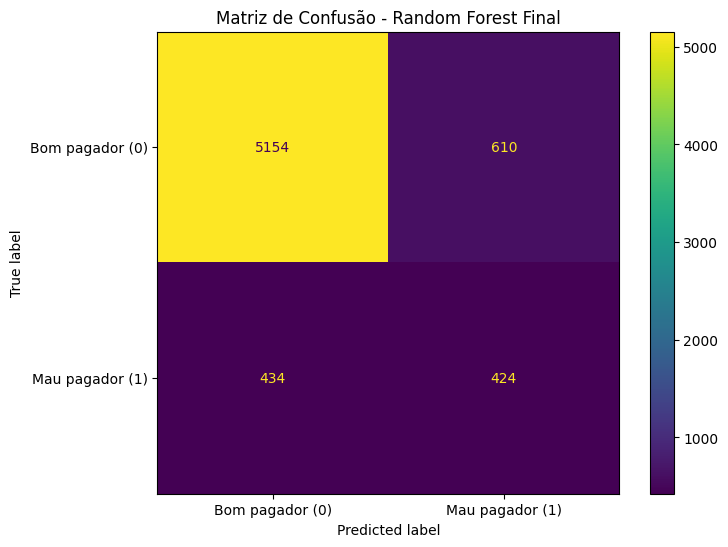

In [126]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    labels=[0, 1],
    display_labels=[
        'Bom pagador (0)',
        'Mau pagador (1)'
    ],
    values_format='d',
    ax=ax
)

plt.title(
    'Matriz de Confusão - Random Forest Final'
)

plt.show()

In [127]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_final
).ravel()

print(tn, fp, fn, tp)

5154 610 434 424


In [128]:
print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_final), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test, y_prob_final), 4)
)

ROC-AUC: 0.7899
PR-AUC: 0.4099


**Encerrar o modelo acadêmico por aqui, deixando F2 - Score, calibração, otimização de hiperparâmetros e definição de threshold por custo financeiro como possibilidades de evolução.**